# Set Up

## Mount Google Drive

Ignore if not using Google Collab:

In [1]:
from google.colab import drive

# mount google drive
drive.mount('/content/drive')
%cd /content/drive/My Drive
!git clone https://github.com/FranciscoLozCoding/cooling_with_code.git
%cd cooling_with_code
!git pull

Mounted at /content/drive
/content/drive/My Drive
fatal: destination path 'cooling_with_code' already exists and is not an empty directory.
/content/drive/My Drive/cooling_with_code
remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 3 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 169.64 KiB | 303.00 KiB/s, done.
From https://github.com/FranciscoLozCoding/cooling_with_code
   e60ba78..00ccb9f  main       -> origin/main
Updating e60ba78..00ccb9f
Fast-forward
 09_mixed_buffers_RandomForestRegressor.ipynb | 1570 +++++++++++++++++++++++++++++++++++++++++++++-
 1 file changed, 1541 insertions(+), 29 deletions(-)
fatal: cannot exec '.git/hooks/post-merge': Permission denied


## Import Libraries

In [2]:
%%capture
%pip install shap
%pip install stackstac
%pip install pystac-client
%pip install planetary-computer
%pip install odc-stac
%pip install rioxarray
%pip install geopy
%pip install geopandas

In [43]:
# Supress Warnings
import warnings
warnings.filterwarnings('ignore')

#data science
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFECV
from sklearn.model_selection import GridSearchCV
import pickle
import shap

#other
import os

#custom tools
from tools.environment import VALID_SPLIT, RANDOM_STATE, TARGET_VARIABLE
from tools.feature_selection import (
    get_feature_importance,
    plot_feature_importance_comparison,
    perm_importance,
    plot_perm_importance_comparison,
    rfe_importance,
    plot_rfe_importance)
from tools.distribution import plot_target_var_distribution
from tools.preprocess import apply_preprocessing_mixed_buffers, load_and_preprocess_data
from tools.explainer import Explainer
from tools.build_dataset import combine_buffer_datasets

In [4]:
train_combined, test_combined = combine_buffer_datasets('data/train', 'data/test')

Loading training data: data/train/50m_buffer_dataset.csv
Loading test data: data/test/50m_buffer_test_dataset.csv
Loading training data: data/train/100m_buffer_dataset.csv
Loading test data: data/test/100m_buffer_test_dataset.csv
Loading training data: data/train/150m_buffer_dataset.csv
Loading test data: data/test/150m_buffer_test_dataset.csv
Loading training data: data/train/300m_buffer_dataset.csv
Loading test data: data/test/300m_buffer_test_dataset.csv

Final Training Dataset Shape: (11229, 77)
Final Test Dataset Shape: (1040, 78)


In [5]:
train_combined, test_combined = apply_preprocessing_mixed_buffers(train_combined, test_combined)


Final Processed Training Dataset Shape: (11229, 164)
Final Processed Testing Dataset Shape: (1040, 165)


# Mixed Buffers RandomForestRegressor

In [6]:
# Separate features and target
y = train_combined['UHI']
X = train_combined.drop('UHI', axis=1)

# Remove constant columns
X = X.loc[:, X.std() != 0]

#scale
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

#split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=VALID_SPLIT, random_state=RANDOM_STATE
)

#make into df
x_train_df = pd.DataFrame(X_train, columns=X.columns)
x_valid_df = pd.DataFrame(X_valid, columns=X.columns)

In [ ]:
# Base Random Forest Model
rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)

# Recursive Feature Elimination with Cross-Validation
rfe = RFECV(estimator=rf, step=1, cv=5, scoring="r2", n_jobs=-1)

# Fit to training data
rfe.fit(x_train_df, y_train)

# Get selected features
selected_features = x_train_df.loc[:, rfe.support_]

# Get names of selected features
selected_feature_names = x_train_df.columns[rfe.support_]

# Print selected feature names
print("Selected Features:", list(selected_feature_names))

In [7]:
# save the selected features so we don't have to run again
selected_feature_names=['50m_1NPCRI', '100m_Elevation_Wind_X', '150m_Traffic_Volume',
                        '150m_Elevation_Wind_Y', '150m_Humidity_NDVI', '150m_Traffic_NDBI',
                        '300m_SI', '300m_NPCRI', '300m_Coastal_Aerosol', '300m_Total_Building_Area_m2',
                        '300m_Building_Construction_Year', '300m_Ground_Elevation', '300m_Building_Wind_X',
                        '300m_Building_Wind_Y', '300m_Elevation_Wind_Y', '300m_BldgHeight_Count',
                        '300m_TotalBuildingArea_NDVI', '300m_Traffic_NDVI', '300m_Traffic_NDBI']

In [8]:
# select features
x_train_selected = pd.DataFrame(X_train, columns=x_train_df.columns)[selected_feature_names]
x_valid_selected = pd.DataFrame(X_valid, columns=x_train_df.columns)[selected_feature_names]

In [ ]:
# Define hyperparameter grid
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}

# Initialize model
rf_model = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)

# Grid search with selected features
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

# Fit grid search to the **selected features only**
grid_search.fit(x_train_selected, y_train)

# Best parameters
print("Best Hyperparameters:", grid_search.best_params_)
print("Best R-squared Score:", grid_search.best_score_)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Hyperparameters: {'bootstrap': False, 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best R-squared Score: 0.9544851498323004


In [ ]:
# save the best params so we don't have to run again
best_hparams = {'bootstrap': False, 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

In [ ]:
# best model, skip if model was already generated
model_pkl = 'models/mixed_buffers_RandomForestRegressor/mixed_buffers_RandomForestRegressor_model.pkl'
model_pkl = 'mixed_buffers_RandomForestRegressor_model.pkl' #temporary, delete later
if not os.path.exists(model_pkl):
  best_rf_model = grid_search.best_estimator_
else:
  with open(model_pkl, 'rb') as f:
    best_rf_model = pickle.load(f)

In [ ]:
# Make predictions on the training data
insample_predictions = best_rf_model.predict(x_train_selected)

# calculate R-squared score for in-sample predictions
print(f"In-Sample Evaluation:")

insample_r2 = r2_score(y_train, insample_predictions)
print(f"  Mixed buffers zone R-squared: {insample_r2}")

In-Sample Evaluation:
  Mixed buffers zone R-squared: 1.0


In [ ]:
# Make predictions on the validation data
outsample_predictions = best_rf_model.predict(x_valid_selected)

# calculate R-squared score for in-sample predictions
print(f"Out-Sample Evaluation:")

outsample_r2 = r2_score(y_valid, outsample_predictions)
print(f"  Mixed buffers zone R-squared: {outsample_r2}")

Out-Sample Evaluation:
  Mixed buffers zone R-squared: 0.9640863723848668


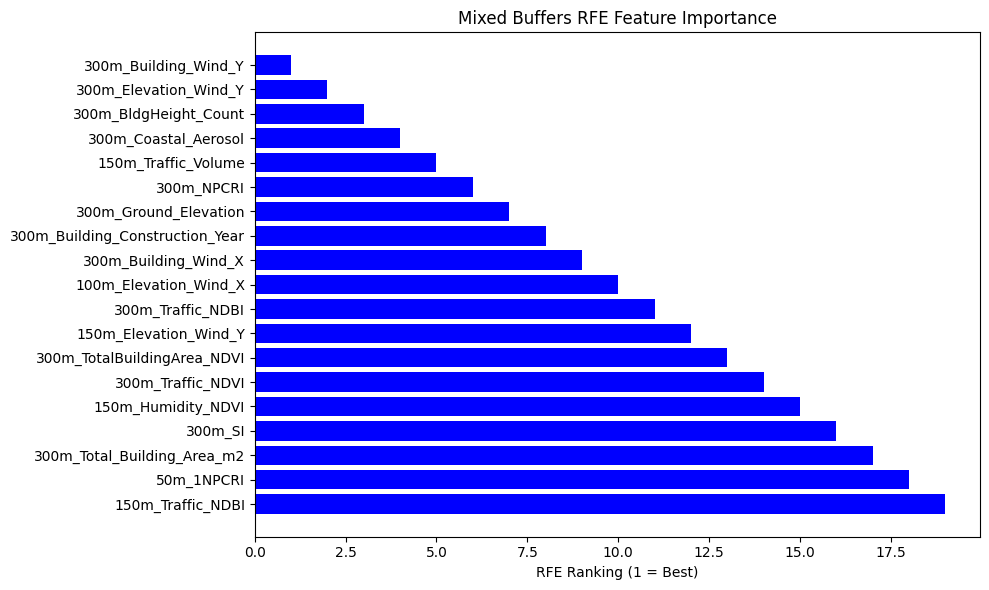

In [ ]:
# Compute RFE feature ranking.
rfe_df = rfe_importance(x_train_selected, y_train, estimator=best_rf_model,
                        n_features_to_select=1, step=1)

# Plot the feature ranking.
plt_obj = plot_rfe_importance(rfe_df, title='Mixed Buffers RFE Feature Importance')
plt_obj.show()

In [ ]:
# Save the model and scaler to files
with open('mixed_buffers_RandomForestRegressor_model.pkl', 'wb') as f:
    pickle.dump(best_rf_model, f)
with open('mixed_buffers_standard_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Correlation Analysis

In [44]:
def conduct_correlation_analysis(df, dataset_name):
    """
    This function conducts a correlation analysis on the DataFrame passed in.

    Args:
        df (pandas.DataFrame): The DataFrame to analyze.
        dataset_name (str): The name of the dataset.

    Returns:
        corr (pandas.DataFrame): The correlation matrix.
        plt (matplotlib.pyplot): The heatmap of the correlation matrix.
    """
    # Compute the correlation matrix.
    corr = df.corr()

    # Create a figure and axis.
    plt.figure(figsize=(12, 6))
    ax = plt.gca()

    # Visualize the correlation matrix using a heatmap.
    sns.heatmap(corr, cmap='coolwarm', ax=ax)

    # Set the title for the heatmap.
    ax.set_title(f'{dataset_name} Correlation')

    # Adjust layout
    plt.tight_layout()

    return corr, plt

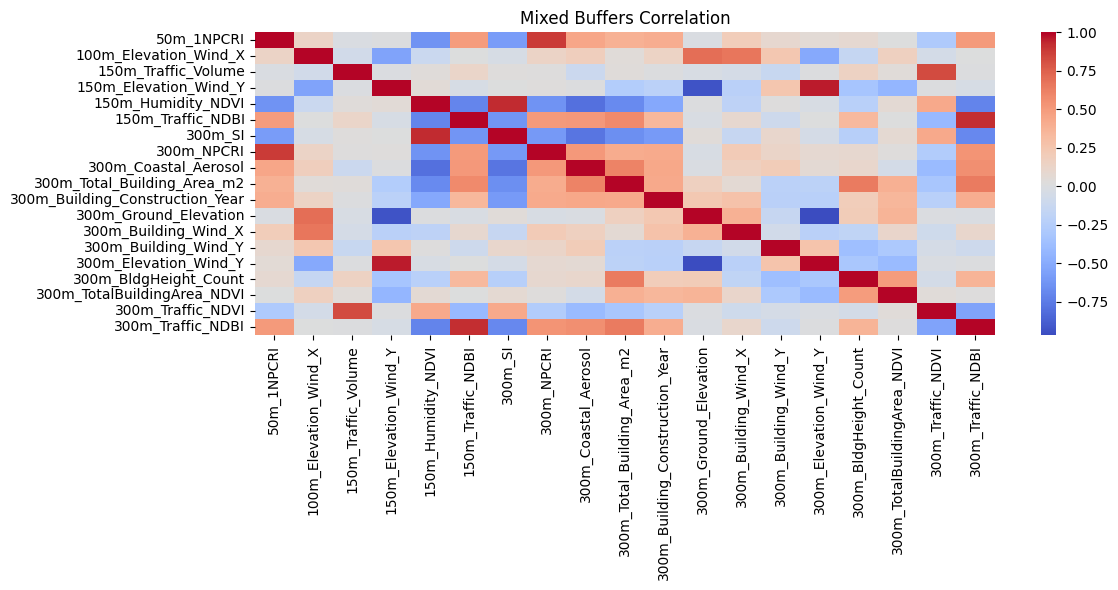

In [46]:
#conduct correlation analysis
corr, plt = conduct_correlation_analysis(x_train_selected, 'Mixed Buffers')
plt.show()

# Neural Network

In [22]:
%%capture
%pip install keras-tuner

In [127]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Input, Add, BatchNormalization, Activation
from tensorflow.keras.regularizers import l1_l2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import keras_tuner as kt
import pandas as pd
import numpy as np

In [ ]:
# Define Feedforward Neural Network
def build_spatial_uhi_model(input_shape):
    model = Sequential([
        Dense(500, activation='relu', input_shape=(input_shape,)),
        Dropout(0.3),
        Dense(400, activation='relu'),
        Dropout(0.3),
        Dense(300, activation='relu'),
        Dropout(0.3),
        Dense(200, activation='relu'),
        Dropout(0.3),
        Dense(100, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='linear')  # Output for UHI
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='mse',
                  metrics=['mae', 'mse'])

    return model

In [ ]:
# Define Feedforward Neural Network with Residual Connections
def build_spatial_uhi_model(input_shape):
    input_layer = Input(shape=(input_shape,))

    # First dense layer
    x = Dense(500, activation='relu')(input_layer)
    x = Dropout(0.3)(x)

    # First Residual Block (500 -> 400)
    x_shortcut = Dense(400, activation='relu')(x)  # Shortcut path
    x = Dense(400, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Add()([x, x_shortcut])  # Adding residual connection

    # Second Residual Block (400 -> 300)
    x_shortcut = Dense(300, activation='relu')(x)
    x = Dense(300, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Add()([x, x_shortcut])

    # Third Residual Block (300 -> 200)
    x_shortcut = Dense(200, activation='relu')(x)
    x = Dense(200, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Add()([x, x_shortcut])

    # Fourth Residual Block (200 -> 100)
    x_shortcut = Dense(100, activation='relu')(x)
    x = Dense(100, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Add()([x, x_shortcut])

    # Output Layer
    output_layer = Dense(1, activation='linear')(x)  # Predict UHI

    # Define Model
    model = Model(inputs=input_layer, outputs=output_layer)

    # Compile Model
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='mse',
                  metrics=['mae', 'mse'])

    return model

In [161]:
# Define tuned Feedforward Neural Network with Residual Connections
def build_spatial_uhi_model(input_shape):
    input_layer = Input(shape=(input_shape,))

    # First dense layer
    x = Dense(1000, activation='relu')(input_layer)
    x = Dropout(0.2)(x)

    # # First dense layer
    # x = Dense(600, activation='relu')(input_layer)
    # x = Dropout(0.2)(x)

    # First Residual Block
    x_shortcut = Dense(800, activation='relu')(x)  # Shortcut path
    x = Dense(800, activation='relu')(x)
    x = Dropout(0.2)(x)
    x = Add()([x, x_shortcut])  # Adding residual connection

    # First Residual Block
    x_shortcut = Dense(600, activation='relu')(x)  # Shortcut path
    x = Dense(600, activation='relu')(x)
    x = Dropout(0.2)(x)
    x = Add()([x, x_shortcut])  # Adding residual connection

    # First Residual Block
    x_shortcut = Dense(500, activation='relu')(x)  # Shortcut path
    x = Dense(500, activation='relu')(x)
    x = Dropout(0.2)(x)
    x = Add()([x, x_shortcut])  # Adding residual connection

    # Second Residual Block
    x_shortcut = Dense(300, activation='relu')(x)
    x = Dense(300, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Add()([x, x_shortcut])

    # Third Residual Block
    x_shortcut = Dense(200, activation='relu')(x)
    x = Dense(200, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Add()([x, x_shortcut])

    # Fourth Residual Block
    x_shortcut = Dense(50, activation='relu')(x)
    x = Dense(50, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Add()([x, x_shortcut])

    # Output Layer
    output_layer = Dense(1, activation='linear')(x)  # Predict UHI

    # Define Model
    model = Model(inputs=input_layer, outputs=output_layer)

    # Use a Learning Rate Scheduler
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.0005,
        decay_steps=10000,
        decay_rate=0.9
    )

    # Compile Model
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
                  loss='mse',
                  metrics=['mae', 'mse'])

    return model

In [ ]:
# Function to build model with tunable hyperparameters
def build_spatial_uhi_model_wTune(hp, input_shape):
    input_layer = Input(shape=(input_shape,))

    # First dense layer
    x = Dense(hp.Int('units_1', min_value=300, max_value=600, step=100), activation='relu')(input_layer)
    x = Dropout(hp.Float('dropout_1', 0.1, 0.5, step=0.1))(x)

    # First Residual Block (500 -> 400)
    x_shortcut = Dense(hp.Int('units_2', 300, 500, 100), activation='relu')(x)
    x = Dense(hp.Int('units_2', 300, 500, 100), activation='relu')(x)
    x = Dropout(hp.Float('dropout_2', 0.1, 0.5, step=0.1))(x)
    x = Add()([x, x_shortcut])

    # Second Residual Block (400 -> 300)
    x_shortcut = Dense(hp.Int('units_3', 200, 400, 100), activation='relu')(x)
    x = Dense(hp.Int('units_3', 200, 400, 100), activation='relu')(x)
    x = Dropout(hp.Float('dropout_3', 0.1, 0.5, step=0.1))(x)
    x = Add()([x, x_shortcut])

    # Third Residual Block (300 -> 200)
    x_shortcut = Dense(hp.Int('units_4', 100, 300, 100), activation='relu')(x)
    x = Dense(hp.Int('units_4', 100, 300, 100), activation='relu')(x)
    x = Dropout(hp.Float('dropout_4', 0.1, 0.5, step=0.1))(x)
    x = Add()([x, x_shortcut])

    # Output Layer
    output_layer = Dense(1, activation='linear')(x)  # Predict UHI

    # Define Model
    model = Model(inputs=input_layer, outputs=output_layer)

    # Compile Model with Tuned Learning Rate
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp.Float('learning_rate', 1e-5, 1e-2, sampling='log')),
                  loss='mse',
                  metrics=['mae', 'mse'])

    return model

In [ ]:
# Build and train model
ann_model = build_spatial_uhi_model(x_train_df.shape[1])

history = ann_model.fit(
    x_train_df, y_train,
    validation_data=(x_valid_df, y_valid),
    epochs=50,  # Adjust based on convergence
    batch_size=32,
    verbose=1
)

In [ ]:
# Plot Learning Curves
plt.figure(figsize=(12, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Training & Validation Loss')
plt.legend()

# Plot MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('Training & Validation MAE')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Make predictions on the training data
insample_predictions = ann_model.predict(x_train_df)

# calculate R-squared score for in-sample predictions
print(f"In-Sample Evaluation:")

insample_r2 = r2_score(y_train, insample_predictions)
print(f"  Mixed buffers zone R-squared: {insample_r2}")

In [ ]:
# Make predictions on the validation data
outsample_predictions = ann_model.predict(x_valid_df)

# calculate R-squared score for in-sample predictions
print(f"Out-Sample Evaluation:")

outsample_r2 = r2_score(y_valid, outsample_predictions)
print(f"  Mixed buffer zone R-squared: {outsample_r2}")

## Feature Selection

In [ ]:
# Use SHAP DeepExplainer
explainer = shap.Explainer(ann_model, x_train_df)
shap_values = explainer(x_train_df)

PermutationExplainer explainer: 7861it [16:04,  8.11it/s]


In [ ]:
# Compute feature importance
feature_importance = np.abs(shap_values.values).mean(axis=0)

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'SHAP Importance': feature_importance
}).sort_values(by='SHAP Importance', ascending=False)


Top Features Based on SHAP:
                         Feature  SHAP Importance
153        300m_BldgHeight_Count         0.001368
133         300m_Coastal_Aerosol         0.000852
132                   300m_NPCRI         0.000834
134          300m_Building_Count         0.000801
117        150m_BldgHeight_Count         0.000789
151        300m_Elevation_Wind_X         0.000590
152        300m_Elevation_Wind_Y         0.000589
159           300m_Humidity_NDMI         0.000563
60                    100m_NPCRI         0.000560
131                    300m_NDMI         0.000555
137         300m_Building_Height         0.000536
139        300m_Ground_Elevation         0.000519
150         300m_Building_Wind_Y         0.000508
136        300m_Building_Density         0.000499
128                    300m_NDBI         0.000499
62           100m_Building_Count         0.000497
135  300m_Total_Building_Area_m2         0.000497
149         300m_Building_Wind_X         0.000479
157    300m_Temp_Buil

In [ ]:
#top features
top_n = 15

# Select the top N important features (e.g., top 20)
selected_feature_names = feature_importance_df['Feature'][:top_n].values

# Print top features
print("\nTop Features Based on SHAP:")
print(feature_importance_df.head(top_n))


Top Features Based on SHAP:
                   Feature  SHAP Importance
153  300m_BldgHeight_Count         0.001368
133   300m_Coastal_Aerosol         0.000852
132             300m_NPCRI         0.000834
134    300m_Building_Count         0.000801
117  150m_BldgHeight_Count         0.000789
151  300m_Elevation_Wind_X         0.000590
152  300m_Elevation_Wind_Y         0.000589
159     300m_Humidity_NDMI         0.000563
60              100m_NPCRI         0.000560
131              300m_NDMI         0.000555


In [ ]:
# save the selected features so we don't have to run again
selected_feature_names = ["300m_BldgHeight_Count", "300m_Coastal_Aerosol", "300m_NPCRI",
                          "300m_Building_Count", "150m_BldgHeight_Count", "300m_Elevation_Wind_X",
                          "300m_Elevation_Wind_Y", "300m_Humidity_NDMI", "100m_NPCRI",
                          "300m_NDMI", "300m_Building_Height", "300m_Ground_Elevation",
                          "300m_Building_Wind_Y", "300m_Building_Density", "300m_NDBI",
                          "100m_Building_Count", "300m_Total_Building_Area_m2", "300m_Building_Wind_X",
                          "300m_Temp_BuildingDensity", "50m_NPCRI"]

In [ ]:
# select features
x_train_selected = pd.DataFrame(X_train, columns=x_train_df.columns)[selected_feature_names]
x_valid_selected = pd.DataFrame(X_valid, columns=x_train_df.columns)[selected_feature_names]

In [162]:
# Retrain model with selected features
ann_model = build_spatial_uhi_model(x_train_selected.shape[1])

history = ann_model.fit(
    x_train_selected, y_train,
    validation_data=(x_valid_selected, y_valid),
    epochs=400,  # Adjust based on convergence
    batch_size=20,
    verbose=1
)

Epoch 1/400
393/393 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 0.6645 - mae: 0.4394 - mse: 0.6645 - val_loss: 0.0149 - val_mae: 0.1035 - val_mse: 0.0149
Epoch 2/400
393/393 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0126 - mae: 0.0842 - mse: 0.0126 - val_loss: 0.0051 - val_mae: 0.0600 - val_mse: 0.0051
Epoch 3/400
393/393 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0052 - mae: 0.0530 - mse: 0.0052 - val_loss: 0.0053 - val_mae: 0.0620 - val_mse: 0.0053
Epoch 4/400
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0023 - mae: 0.0358 - mse: 0.0023 - val_loss: 0.0020 - val_mae: 0.0399 - val_mse: 0.0020
Epoch 5/400
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0011 - mae: 0.0256 - mse: 0.0011 - val_loss: 0.0017 - val_mae: 0.0385 - val_mse: 0.0017
Epoch 6/400
393/393 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0040 - mae: 0.0345 - mse: 0.0040 - val_loss: 4.9329e-04 - val_mae: 0.0181 - val_mse: 4.9329e-04
Epoch 7/400
393/393 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 6.7430e-04 - mae: 0.0184

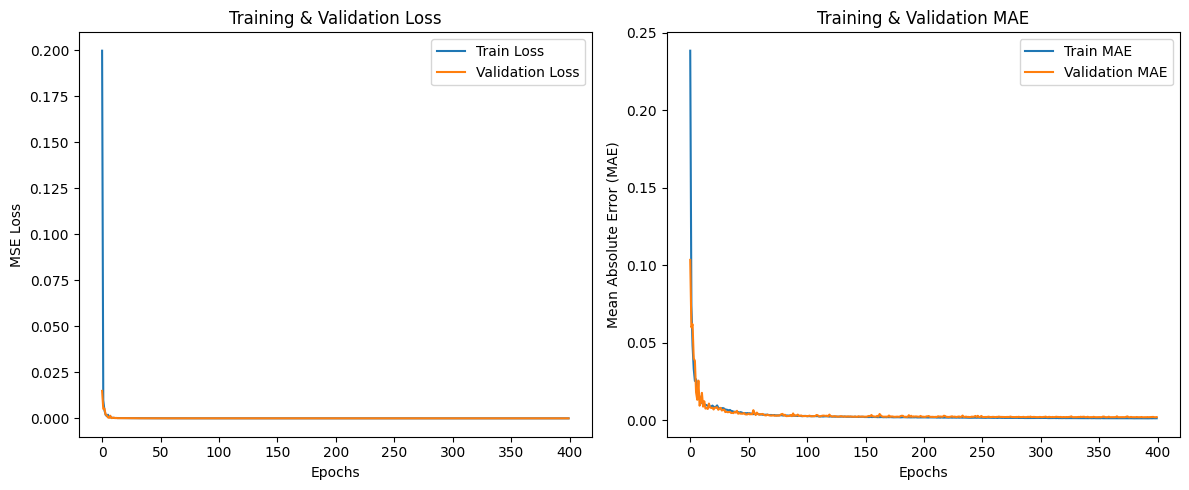

In [163]:
# Plot Learning Curves
plt.figure(figsize=(12, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Training & Validation Loss')
plt.legend()

# Plot MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('Training & Validation MAE')
plt.legend()

plt.tight_layout()
plt.show()

In [164]:
# Make predictions on the training data
insample_predictions = ann_model.predict(x_train_selected)

# calculate R-squared score for in-sample predictions
print(f"In-Sample Evaluation:")

insample_r2 = r2_score(y_train, insample_predictions)
print(f"  Mixed buffers zone R-squared: {insample_r2}")

246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
In-Sample Evaluation:
  Mixed buffers zone R-squared: 0.9909904301064592


In [165]:
# Make predictions on the validation data
outsample_predictions = ann_model.predict(x_valid_selected)

# calculate R-squared score for in-sample predictions
print(f"Out-Sample Evaluation:")

outsample_r2 = r2_score(y_valid, outsample_predictions)
print(f"  Mixed buffer zone R-squared: {outsample_r2}")

106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Out-Sample Evaluation:
  Mixed buffer zone R-squared: 0.9632485527053526


## Tuning Hyperparameters

In [ ]:
# Define Hyperparameter Search Space
tuner = kt.BayesianOptimization(
    lambda hp: build_spatial_uhi_model_wTune(hp, input_shape=x_train_selected.shape[1]),  # Pass input_shape
    objective='val_mae',
    max_trials=20,  # Number of different models to try
    executions_per_trial=1,  # Number of times each model is trained
    directory='hyperparam_tuning',
    project_name='UHI_ResNet_Tuning'
)

# Run Hyperparameter Search
tuner.search(x_train_selected, y_train, epochs=50,
             validation_data=(x_valid_selected, y_valid), batch_size=32)

Trial 20 Complete [00h 00m 56s]
val_mae: 0.005529041867703199

Best val_mae So Far: 0.0043893842957913876
Total elapsed time: 00h 21m 55s


In [ ]:
# Get Best Model
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = tuner.hypermodel.build(best_hps)

# Train the best model
history = best_model.fit(x_train_selected, y_train,
                         validation_data=(x_valid_selected, y_valid),
                         epochs=100, batch_size=32)

Epoch 1/100
246/246 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.2418 - mae: 0.3066 - mse: 0.2418 - val_loss: 0.0144 - val_mae: 0.1089 - val_mse: 0.0144
Epoch 2/100
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0104 - mae: 0.0755 - mse: 0.0104 - val_loss: 0.0082 - val_mae: 0.0505 - val_mse: 0.0082
Epoch 3/100
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0060 - mae: 0.0570 - mse: 0.0060 - val_loss: 0.0019 - val_mae: 0.0303 - val_mse: 0.0019
Epoch 4/100
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0029 - mae: 0.0382 - mse: 0.0029 - val_loss: 0.0025 - val_mae: 0.0434 - val_mse: 0.0025
Epoch 5/100
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0015 - mae: 0.0289 - mse: 0.0015 - val_loss: 5.0190e-04 - val_mae: 0.0170 - val_mse: 5.0190e-04
Epoch 6/100
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9.3098e-04 - mae: 0.0228 - mse: 9.3098e-04 - val_loss: 7.5535e-04 - val_mae: 0.0234 - val_mse: 7.5535e-04
Epoch 7/100
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9.0216e-

In [ ]:
# save best hp so we don't have to run tuner again
best_hps_dict = {'first_Layer_units': 600,
 'first_Layer_dropout': 0.2,
 'second_residual_block_units': 500,
 'second_residual_block_dropout': 0.2,
 'third_residual_block_units': 300,
 'third_residual_block_dropout': 0.5,
 'fourth_residual_block_units': 200,
 'fourth_residual_block_units_dropout': 0.5,
 'learning_rate': 0.0005702557437126698}

In [ ]:
# Make predictions on the training data
insample_predictions = best_model.predict(x_train_selected)

# calculate R-squared score for in-sample predictions
print(f"In-Sample Evaluation:")

insample_r2 = r2_score(y_train, insample_predictions)
print(f"  Mixed buffers zone R-squared: {insample_r2}")

246/246 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
In-Sample Evaluation:
  Mixed buffers zone R-squared: 0.9481684075045763


In [ ]:
# Make predictions on the validation data
outsample_predictions = best_model.predict(x_valid_selected)

# calculate R-squared score for in-sample predictions
print(f"Out-Sample Evaluation:")

outsample_r2 = r2_score(y_valid, outsample_predictions)
print(f"  Mixed buffer zone R-squared: {outsample_r2}")

106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Out-Sample Evaluation:
  Mixed buffer zone R-squared: 0.9273300692984785


In [ ]:
# Save the best model
best_model.save("mixed_buffers_ResNet_model.keras")

In [ ]:
# Save model
ann_model.save("mixed_buffers_Feedforward_ANN_model.keras")

# NOTES

- Using the features selected by Random forest does better than doing feature selectio using my ResNet model
- Using smaller neaurons in my first later gave me a worse score, so I had to increase it. Meaning Increasing the neuron count helped capture more detailed patterns in the data.
- ResNet helped in making my neural network better.
- Using Adaptive Learning Rate helped in making my neural network better
- The mixed buffer dataset improved my Random Forest model
- Also using the mixed buffer dataset helped improve my neural network model
-